# Tarea 2 -- Modelo de propension: em_acount

easyMoney - TFM Nuclio Digital School

Segundo modelo de propension, sobre `em_acount` (producto secundario de alto valor). Mismo enfoque metodologico que `03_modelling_pension_plan.ipynb` (incluido el cambio de arbol de decision unico a Random Forest, para evitar que muchos clientes queden empatados en la misma probabilidad), aplicado a un producto distinto para comprobar que el metodo generaliza. Parte del panel guardado por `02_preprocessing_propension.ipynb`.

Una diferencia respecto al notebook de `pension_plan`: aqui SI incluimos `pension_plan_lag1` como feature (ya no es una columna constante para este modelo, y puede aportar senal: si ya tiene `pension_plan`, puede predecir su interes por `em_acount`). La columna que ahora se convierte en constante (y por tanto se excluye como feature) es `em_acount_lag1`, que usamos solo para filtrar el universo elegible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df_panel = pd.read_parquet('../data/processed/df_panel_propension.parquet', engine='pyarrow')
print(df_panel.shape)

(5961849, 39)


## 1. Target: adquisicion nueva de em_acount

In [2]:
df_panel['target_em_acount'] = df_panel.groupby('pk_cid')['em_acount'].diff()
df_panel['target_em_acount'] = df_panel['target_em_acount'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target_em_acount'].value_counts())

target_em_acount
0    5920923
1      40926
Name: count, dtype: int64


## 2. Universo elegible

Filtramos a clientes que el mes anterior NO tenian `em_acount`. `em_acount` es un producto mucho mas extendido que `pension_plan`, asi que el universo elegible es bastante mas pequeno (menos clientes 'sin el producto'), pero el desbalanceo del target es mas suave.

Igual que en `pension_plan`, se anaden `region_code_lag1`, `antiguedad_meses_lag1` y `mes` (esta ultima sin lag, ver notebook de preprocessing) como features nuevas.

In [3]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products', 'region_code', 'antiguedad_meses']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['em_acount_lag1', 'pension_plan_lag1']

df_model_em = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model_em = df_model_em[df_model_em['em_acount_lag1'] == 0].copy()

print('Filas tras filtrar elegibles (em_acount):', df_model_em.shape)
print(df_model_em['target_em_acount'].value_counts())

Filas tras filtrar elegibles (em_acount): (1421026, 40)
target_em_acount
0    1380100
1      40926
Name: count, dtype: int64


## 3. Split temporal (train / test / validacion)

In [4]:
meses = sorted(df_model_em['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train_em = df_model_em[df_model_em['pk_partition'] < mes_test]
test_em  = df_model_em[df_model_em['pk_partition'] == mes_test]
val_em   = df_model_em[df_model_em['pk_partition'] == mes_val]

print('Train:', train_em.shape)
print('Test: ', test_em.shape)
print('Val:  ', val_em.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (1138456, 40)
Test:  (139972, 40)
Val:   (142598, 40)


## 4. Codificacion de variables

Agrupamos `entry_channel` raras calculando la frecuencia SOLO con `train_em` (no reciclamos el calculo del notebook de `pension_plan`, porque el universo de filas es distinto).

In [5]:
frecuencias_em = train_em['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes_em = frecuencias_em[frecuencias_em >= 0.01].index

def agrupar_entry_channel_em(serie):
    return serie.where(serie.isin(categorias_frecuentes_em), 'Otros')

train_em = train_em.copy()
test_em = test_em.copy()
val_em = val_em.copy()
train_em['entry_channel_lag1'] = agrupar_entry_channel_em(train_em['entry_channel_lag1'])
test_em['entry_channel_lag1']  = agrupar_entry_channel_em(test_em['entry_channel_lag1'])
val_em['entry_channel_lag1']   = agrupar_entry_channel_em(val_em['entry_channel_lag1'])

print('Categorias tras agrupar:', train_em['entry_channel_lag1'].nunique())

# region_code_lag1 y mes van en cat_cols: son codigos/categorias, no cantidades continuas.
cat_cols_em = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1', 'region_code_lag1', 'mes']
num_cols_em = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1',
               'antiguedad_meses_lag1', 'pension_plan_lag1']

X_train_em = pd.get_dummies(train_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_test_em  = pd.get_dummies(test_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_val_em   = pd.get_dummies(val_em[num_cols_em + cat_cols_em], columns=cat_cols_em)

X_test_em = X_test_em.reindex(columns=X_train_em.columns, fill_value=0)
X_val_em  = X_val_em.reindex(columns=X_train_em.columns, fill_value=0)

y_train_em = train_em['target_em_acount']
y_test_em  = test_em['target_em_acount']
y_val_em   = val_em['target_em_acount']

print('X_train_em:', X_train_em.shape)
print('X_test_em: ', X_test_em.shape)
print('X_val_em:  ', X_val_em.shape)

Categorias tras agrupar: 12
X_train_em: (1138456, 88)
X_test_em:  (139972, 88)
X_val_em:   (142598, 88)


## 5. Modelo

Igual que en `pension_plan`, usamos Random Forest en lugar de un unico arbol de decision, por la misma razon: un arbol unico da pocas probabilidades distintas, generando empates al ordenar clientes por probabilidad.

**Por que `max_depth=15`.** Se probaron varias profundidades (3, 5, 7, 10, 15, sin limite) evaluando siempre contra TEST. El resultado crecio de forma sostenida hasta profundidad 15 (1.348 compras capturadas en el top 5% de test, frente a 1.091 con profundidad 5) y cayo con fuerza sin limite (963 compras, peor incluso que profundidad 3) -- señal clara de sobreajuste. `max_depth=15` es el mismo valor optimo que en `pension_plan`, lo que da consistencia al criterio de eleccion entre los dos modelos.

In [6]:
modelo_em = RandomForestClassifier(
    n_estimators=300, max_depth=15, class_weight='balanced',
    random_state=42, n_jobs=-1
)
modelo_em.fit(X_train_em, y_train_em)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)

## 6. Evaluacion tecnica (sobre el mes de test)

Valores de probabilidad distintos en test: 107420 de 139972 clientes
              precision    recall  f1-score   support

   No compra       1.00      0.79      0.88    137392
      Compra       0.07      0.80      0.12      2580

    accuracy                           0.79    139972
   macro avg       0.53      0.79      0.50    139972
weighted avg       0.98      0.79      0.87    139972



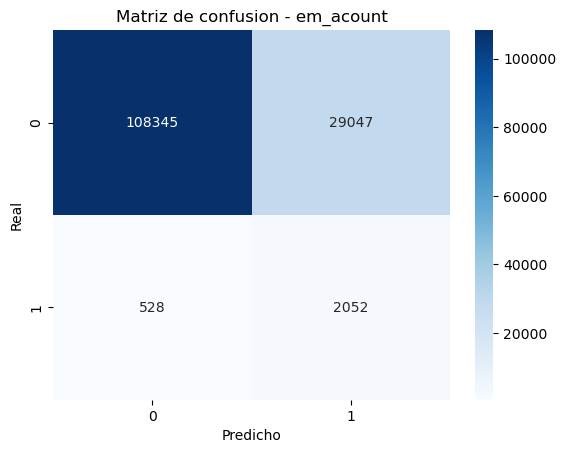

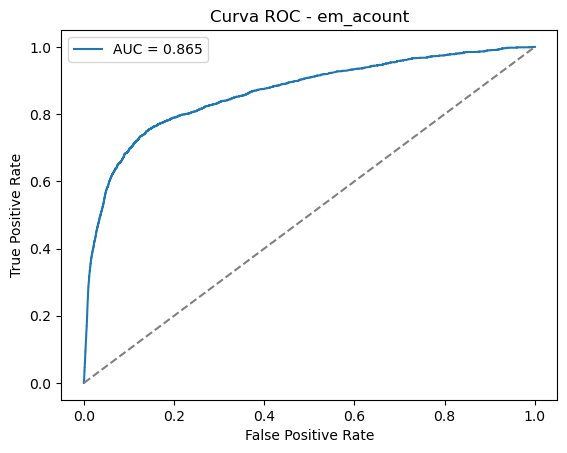

In [7]:
y_pred_em = modelo_em.predict(X_test_em)
y_proba_em = modelo_em.predict_proba(X_test_em)[:, 1]

print(f'Valores de probabilidad distintos en test: {pd.Series(y_proba_em).nunique()} de {len(y_proba_em)} clientes')


print(classification_report(y_test_em, y_pred_em, target_names=['No compra', 'Compra']))

cm_em = confusion_matrix(y_test_em, y_pred_em)
sns.heatmap(cm_em, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - em_acount')
plt.show()

fpr_em, tpr_em, _ = roc_curve(y_test_em, y_proba_em)
roc_auc_em = auc(fpr_em, tpr_em)
plt.plot(fpr_em, tpr_em, label=f'AUC = {roc_auc_em:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - em_acount')
plt.legend()
plt.show()

## 7. Evaluacion de negocio: conversion real en el top 5%

In [8]:
val_proba_em = modelo_em.predict_proba(X_val_em)[:, 1]
print(f'Valores de probabilidad distintos en validacion: {pd.Series(val_proba_em).nunique()} de {len(val_proba_em)} clientes')

df_sim_em = pd.DataFrame({
    'pk_cid': val_em['pk_cid'].values,
    'probabilidad': val_proba_em,
    'compra_real': y_val_em.values
}).sort_values(by='probabilidad', ascending=False)

top_pct = 0.05
top_n_em = int(len(df_sim_em) * top_pct)
top_clientes_em = df_sim_em.head(top_n_em)

compras_en_top_em = top_clientes_em['compra_real'].sum()
tasa_conversion_top_em = compras_en_top_em / top_n_em
tasa_base_em = df_sim_em['compra_real'].mean()

print(f'Clientes evaluados en validacion: {len(df_sim_em)}')
print(f'Clientes en el top {top_pct*100:.0f}%: {top_n_em}')
print(f'Compras reales dentro del top: {compras_en_top_em}')
print(f'Tasa de conversion en el top {top_pct*100:.0f}%: {tasa_conversion_top_em*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base_em*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top_em/tasa_base_em:.1f} frente a contactar al azar')

Valores de probabilidad distintos en validacion: 110394 de 142598 clientes
Clientes evaluados en validacion: 142598
Clientes en el top 5%: 7129
Compras reales dentro del top: 1261
Tasa de conversion en el top 5%: 17.69%
Tasa de conversion si contactases al azar: 1.73%
El modelo mejora la conversion x10.2 frente a contactar al azar


## Resumen de resultados (em_acount)

**Pendiente de recalcular** tras cambiar a max_depth=15 (25/08/2026). Ejecuta el notebook completo de arriba a abajo y sustituye este bloque con los valores reales de conversion en el top 5%, AUC y recall/precision que obtengas en VALIDACION (mayo 2019).

Referencia de la busqueda de profundidad (evaluada en TEST, no en validacion): max_depth=15 dio 1.348 compras / 19.26% conversion / x10.5 en test -- el resultado final en validacion sera distinto (validacion es un mes distinto, mayo en vez de abril) pero deberia ser del mismo orden de magnitud.

## 8. Scoring final: clientes reales a contactar hoy

Todo lo anterior evaluaba el modelo contra meses ya conocidos. Aquí lo aplicamos
de verdad: cogemos el estado de cada cliente en el último mes disponible y
predecimos su propensión para el mes siguiente (uno que todavía no ha pasado).

In [9]:
ultimo_mes_em = df_model_em['pk_partition'].max()
df_actual_em = df_panel[df_panel['pk_partition'] == ultimo_mes_em].copy()

df_actual_em = df_actual_em[df_actual_em['em_acount'] == 0].copy()

df_actual_em['entry_channel'] = df_actual_em['entry_channel'].where(
    df_actual_em['entry_channel'].isin(categorias_frecuentes_em), 'Otros'
)

# El 'mes' es el mes que se está PREDICIENDO (el siguiente al último disponible)
mes_prediccion_em = (ultimo_mes_em + pd.DateOffset(months=1)).month
df_actual_em['mes'] = str(mes_prediccion_em).zfill(2)

X_actual_em = pd.get_dummies(
    df_actual_em[['age', 'salary', 'active_customer', 'num_products', 'pension_plan',
                  'region_code', 'antiguedad_meses', 'gender', 'segment', 'entry_channel', 'mes']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'pension_plan': 'pension_plan_lag1',
        'region_code': 'region_code_lag1', 'antiguedad_meses': 'antiguedad_meses_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1', 'region_code_lag1', 'mes']
)
X_actual_em = X_actual_em.reindex(columns=X_train_em.columns, fill_value=0)

proba_actual_em = modelo_em.predict_proba(X_actual_em)[:, 1]
print(f'Mes que se predice: {mes_prediccion_em:02d}')
print(f'Valores de probabilidad distintos en el scoring final: {pd.Series(proba_actual_em).nunique()} de {len(proba_actual_em)} clientes')

df_scoring_em = pd.DataFrame({
    'pk_cid': df_actual_em['pk_cid'].values,
    'probabilidad_em_acount': proba_actual_em
}).sort_values(by='probabilidad_em_acount', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para em_acount hoy: {len(df_scoring_em)}')
print(df_scoring_em.head(20))

df_scoring_em.to_csv('../data/processed/scoring_em_acount.csv', index=False)
print('Guardado en ../data/processed/scoring_em_acount.csv')

Mes que se predice: 06
Valores de probabilidad distintos en el scoring final: 111355 de 146575 clientes
Clientes elegibles para em_acount hoy: 146575
     pk_cid  probabilidad_em_acount
0   1278042                0.933733
1   1282142                0.932848
2   1174377                0.931930
3   1219192                0.931225
4   1182603                0.931059
5   1334733                0.930034
6   1343367                0.929853
7   1222434                0.929371
8   1139418                0.929090
9   1175121                0.927962
10  1312136                0.927943
11  1188416                0.927868
12  1185132                0.927790
13  1304987                0.927610
14  1343481                0.927586
15  1333709                0.926677
16  1352306                0.926603
17  1176045                0.926238
18  1177352                0.926177
19  1219461                0.926091
Guardado en ../data/processed/scoring_em_acount.csv


In [10]:
df_sim_em.to_csv("../data/processed/validacion_em_acount.csv", index=False)
print("Guardado validacion_em_acount.csv:", df_sim_em.shape)

Guardado validacion_em_acount.csv: (142598, 3)
